In [30]:
# ==============================================================================
# Build and evaluate an LSTM model for time series prediction Objective:
# ==============================================================================

#Step 2: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [31]:
#Step 3: Load Dataset

import pandas as pd

# Load dataset
df = pd.read_csv("E:\Artificial Intelligence\AirPassengers.csv")

# Show dataset
print(df.head())

     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121


In [32]:
#Step 3: Convert Date Column

df['Month'] = pd.to_datetime(df['Month'])

print(df.head())

       Month  #Passengers
0 1949-01-01          112
1 1949-02-01          118
2 1949-03-01          132
3 1949-04-01          129
4 1949-05-01          121


In [33]:
#Step 4: Set Date Column as Index

df.set_index('Month', inplace=True)

print(df.head())

            #Passengers
Month                  
1949-01-01          112
1949-02-01          118
1949-03-01          132
1949-04-01          129
1949-05-01          121


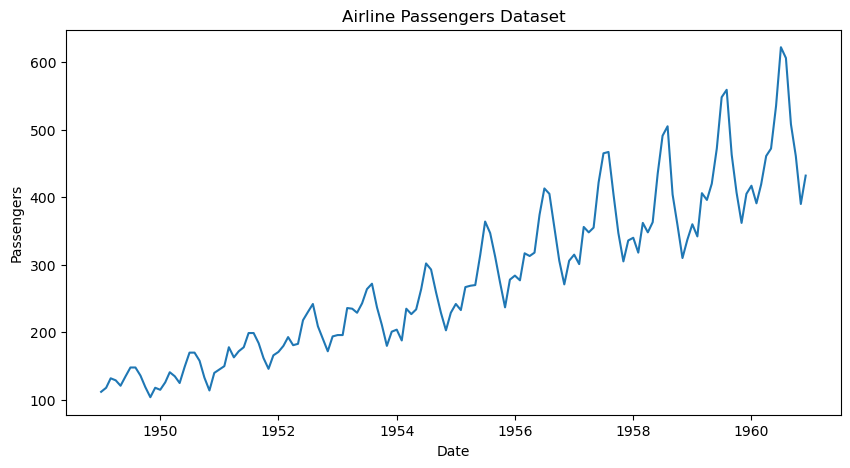

In [34]:
#Step 5: Plot Time Series Data

plt.figure(figsize=(10,5))

plt.plot(df['#Passengers'])

plt.title("Airline Passengers Dataset")

plt.xlabel("Date")

plt.ylabel("Passengers")

plt.show()

In [35]:
#Step 6: Select Passenger Column

data = df[['#Passengers']].values

print(data[:5])

[[112]
 [118]
 [132]
 [129]
 [121]]


In [36]:
#Step 7: Normalize Data

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

print(scaled_data[:5])

[[0.01544402]
 [0.02702703]
 [0.05405405]
 [0.04826255]
 [0.03281853]]


In [37]:
#Step 8: Create Time Series Sequences

sequence_length = 10

X = []
y = []

for i in range(len(scaled_data) - sequence_length):

    X.append(scaled_data[i:i+sequence_length])

    y.append(scaled_data[i+sequence_length])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(134, 10, 1)
(134, 1)


In [38]:
#Step 9: Train-Test Split

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape)
print(X_test.shape)

(107, 10, 1)
(27, 10, 1)


In [39]:
#Step 10: Convert to PyTorch Tensors

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [40]:
#Step 11: Create DataLoader

batch_size = 16

train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [41]:
#Step 12: Build LSTM Model

class LSTMModel(nn.Module):

    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):

        super(LSTMModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        out, _ = self.lstm(x, (h0, c0))

        out = out[:, -1, :]

        out = self.fc(out)

        return out

In [42]:
#Step 13: Initialize Model

model = LSTMModel()

print(model)

LSTMModel(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


In [43]:
#Step 14: Define Loss Function and Optimizer

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [44]:
#Step 15: Train the Model

epochs = 50

losses = []

for epoch in range(epochs):

    for inputs, targets in train_loader:

        outputs = model(inputs)

        loss = criterion(outputs, targets)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    losses.append(loss.item())

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

Epoch [1/50], Loss: 0.306719
Epoch [2/50], Loss: 0.176629
Epoch [3/50], Loss: 0.065697
Epoch [4/50], Loss: 0.037073
Epoch [5/50], Loss: 0.053512
Epoch [6/50], Loss: 0.068979
Epoch [7/50], Loss: 0.068708
Epoch [8/50], Loss: 0.059535
Epoch [9/50], Loss: 0.051661
Epoch [10/50], Loss: 0.049367
Epoch [11/50], Loss: 0.049887
Epoch [12/50], Loss: 0.048851
Epoch [13/50], Loss: 0.045083
Epoch [14/50], Loss: 0.040410
Epoch [15/50], Loss: 0.036337
Epoch [16/50], Loss: 0.032226
Epoch [17/50], Loss: 0.027261
Epoch [18/50], Loss: 0.023281
Epoch [19/50], Loss: 0.023336
Epoch [20/50], Loss: 0.027178
Epoch [21/50], Loss: 0.027011
Epoch [22/50], Loss: 0.025621
Epoch [23/50], Loss: 0.023468
Epoch [24/50], Loss: 0.023808
Epoch [25/50], Loss: 0.022944
Epoch [26/50], Loss: 0.024084
Epoch [27/50], Loss: 0.022848
Epoch [28/50], Loss: 0.024013
Epoch [29/50], Loss: 0.022436
Epoch [30/50], Loss: 0.023422
Epoch [31/50], Loss: 0.022048
Epoch [32/50], Loss: 0.022925
Epoch [33/50], Loss: 0.021754
Epoch [34/50], Loss

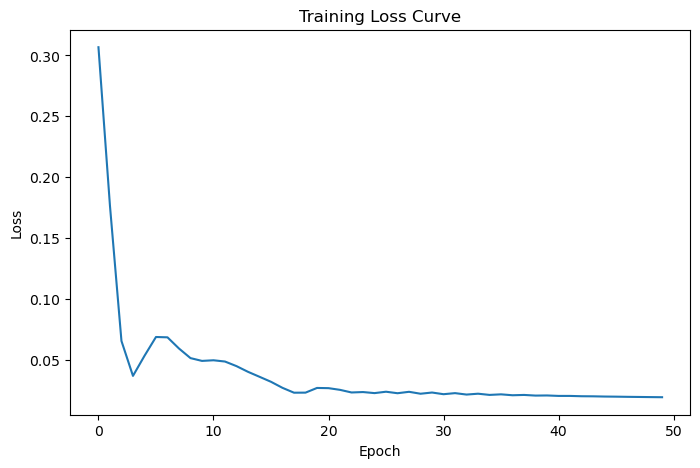

In [45]:
#Step 16: Plot Training Loss Curve

plt.figure(figsize=(8,5))

plt.plot(losses)

plt.title("Training Loss Curve")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

In [46]:
#Step 17: Make Predictions

model.eval()

with torch.no_grad():

    predictions = model(X_test)

predictions = predictions.numpy()

actual = y_test.numpy()

In [47]:
#Step 18: Convert Back to Original Values

predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(actual)

In [48]:
#Step 19: Calculate MSE and RMSE

mse = mean_squared_error(actual, predictions)

rmse = np.sqrt(mse)

print("MSE:", mse)

print("RMSE:", rmse)

MSE: 6631.59423828125
RMSE: 81.43460098926776


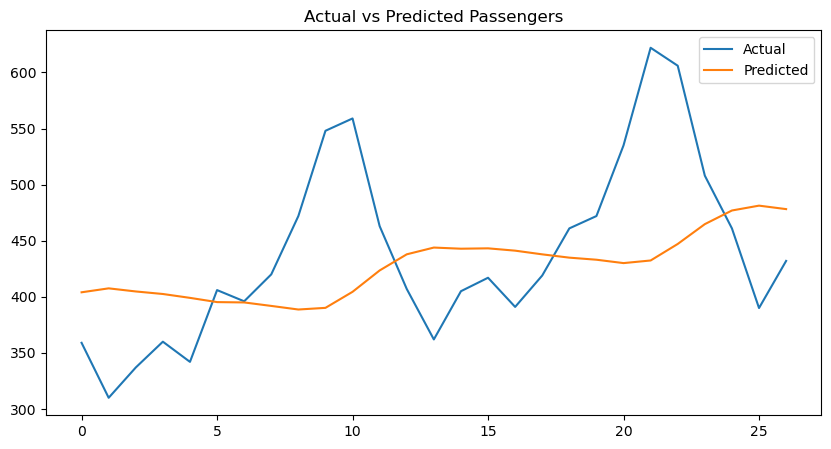

In [49]:
#Step 20: Plot Actual vs Predicted Values

plt.figure(figsize=(10,5))

plt.plot(actual, label="Actual")

plt.plot(predictions, label="Predicted")

plt.legend()

plt.title("Actual vs Predicted Passengers")

plt.show()

In [50]:
#Step 21: Hyperparameter Tuning

#Change Hidden Units
model = LSTMModel(hidden_size=100)

#Change Number of Layers
model = LSTMModel(num_layers=3)

#Change Learning Rate
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005
)

#Change Sequence Length
sequence_length = 20

In [51]:
# =========================================================================
#2.(Bonus Task) Build a Text Classification Model using LSTM
# =========================================================================

#Step 1: Import Libraries
import torch
import torch.nn as nn
from torchtext.data.utils import get_tokenizer
from collections import Counter

In [52]:
#Step 2: Example Dataset

texts = [
    "I love this movie",
    "This movie is bad",
    "Amazing film",
    "Worst acting"
]

labels = [1, 0, 1, 0]

In [53]:
#Step 3: Tokenization

tokenizer = get_tokenizer('basic_english')

tokens = [tokenizer(text) for text in texts]

print(tokens)

[['i', 'love', 'this', 'movie'], ['this', 'movie', 'is', 'bad'], ['amazing', 'film'], ['worst', 'acting']]


In [54]:
#Step 4: Build Vocabulary

vocab = {}

for text in texts:

    for word in text.lower().split():

        if word not in vocab:

            vocab[word] = len(vocab) + 1

print(vocab)

{'i': 1, 'love': 2, 'this': 3, 'movie': 4, 'is': 5, 'bad': 6, 'amazing': 7, 'film': 8, 'worst': 9, 'acting': 10}


In [55]:
#Step 5: Convert Text to Sequences

sequences = []

for text in texts:

    seq = [vocab[word] for word in text.lower().split()]

    sequences.append(seq)

print(sequences)

[[1, 2, 3, 4], [3, 4, 5, 6], [7, 8], [9, 10]]


In [56]:
#Step 6: Padding Sequences

max_len = 5

padded = []

for seq in sequences:

    seq = seq + [0] * (max_len - len(seq))

    padded.append(seq)

print(padded)

[[1, 2, 3, 4, 0], [3, 4, 5, 6, 0], [7, 8, 0, 0, 0], [9, 10, 0, 0, 0]]


In [57]:
#Step 7: Convert to Tensors

X = torch.LongTensor(padded)

y = torch.FloatTensor(labels).view(-1,1)

print(X.shape)
print(X.dtype)

print(y.shape)
print(y.dtype)

torch.Size([4, 5])
torch.int64
torch.Size([4, 1])
torch.float32


In [58]:
#Step 8: Build LSTM Text Classifier

class TextLSTM(nn.Module):

    def __init__(self, vocab_size, embed_size, hidden_size):

        super(TextLSTM, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_size)

        self.lstm = nn.LSTM(
            embed_size,
            hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        x = self.embedding(x)

        out, _ = self.lstm(x)

        out = out[:, -1, :]

        out = self.fc(out)

        out = self.sigmoid(out)

        return out

In [59]:
#Step 9: Initialize Model

model = TextLSTM(
    vocab_size=len(vocab)+1,
    embed_size=8,
    hidden_size=16
)

print(model)

TextLSTM(
  (embedding): Embedding(11, 8)
  (lstm): LSTM(8, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [60]:
#Step 10: Loss and Optimizer

criterion = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [61]:
#Step 11: Train the Model

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 100

for epoch in range(epochs):

    outputs = model(X)

    loss = criterion(outputs, y)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.7287
Epoch 2, Loss: 0.7282
Epoch 3, Loss: 0.7276
Epoch 4, Loss: 0.7270
Epoch 5, Loss: 0.7265
Epoch 6, Loss: 0.7259
Epoch 7, Loss: 0.7254
Epoch 8, Loss: 0.7249
Epoch 9, Loss: 0.7243
Epoch 10, Loss: 0.7238
Epoch 11, Loss: 0.7232
Epoch 12, Loss: 0.7227
Epoch 13, Loss: 0.7222
Epoch 14, Loss: 0.7216
Epoch 15, Loss: 0.7211
Epoch 16, Loss: 0.7206
Epoch 17, Loss: 0.7200
Epoch 18, Loss: 0.7195
Epoch 19, Loss: 0.7190
Epoch 20, Loss: 0.7184
Epoch 21, Loss: 0.7179
Epoch 22, Loss: 0.7173
Epoch 23, Loss: 0.7168
Epoch 24, Loss: 0.7162
Epoch 25, Loss: 0.7156
Epoch 26, Loss: 0.7151
Epoch 27, Loss: 0.7145
Epoch 28, Loss: 0.7139
Epoch 29, Loss: 0.7133
Epoch 30, Loss: 0.7127
Epoch 31, Loss: 0.7121
Epoch 32, Loss: 0.7115
Epoch 33, Loss: 0.7109
Epoch 34, Loss: 0.7102
Epoch 35, Loss: 0.7096
Epoch 36, Loss: 0.7089
Epoch 37, Loss: 0.7083
Epoch 38, Loss: 0.7076
Epoch 39, Loss: 0.7069
Epoch 40, Loss: 0.7062
Epoch 41, Loss: 0.7055
Epoch 42, Loss: 0.7048
Epoch 43, Loss: 0.7040
Epoch 44, Loss: 0.70

In [62]:
#Step 12: Prediction

with torch.no_grad():

    predictions = model(X).squeeze()

print(predictions)

tensor([0.7910, 0.2119, 0.3002, 0.1298])


In [63]:
#Step 13: Convert Predictions to Classes

predicted_classes = (predictions >= 0.5).int()

print(predicted_classes)

tensor([1, 0, 0, 0], dtype=torch.int32)
